# Genetic Rock Paper Scissors

The original paper shows how, in a _three-way_ prey-predator model, the
unexpected emerging behavior is a sort of _survival of the weakest_, where the
least aggressive species are the ones the most likely will have an higher
population density.

The model does not involve movement but only space conquering by hunting a
nearby cell, which will host the offspring of the predator. The offspring
inherit the invasion probability from the father

- Just by copying it:
  $$ p_\text{new} = p_\text{old} $$
- With a random mutation:
  $$ p_\text{new} = p_\text{old} + \varepsilon $$
  with $\varepsilon \sim \cal{N} (0, 0.01)$

The study shows mainly two cases: 

- Two of the three species invasion probability are held constant, while the
  third is free to evolve through random mutations.
- All three species are free to mutate.

The paper also says how the mutation, in general, drive the population to be
more aggressive on average, that results in:

- A reduced population of the specie free to evolve (first case).
- A dynamical equilibrium, made possible by all three species reaching maximal
  aggression (second case).

## Paper Results Reproduction

The first thing to do is to have a baseline by reproducing the dynamics
described in the paper on a $50 \times 50$ and a maximum of $2000$ epochs
simulation.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import mesa

from grps import RPSModel
import grps.evolution_policies as evo


def plot_densities(data: pd.DataFrame) -> None:
    plt.figure(dpi=150)
    plt.title("Population Density")
    plt.plot(data["R_density"], c="red", label="rock")
    plt.plot(data["P_density"], c="blue", label="paper")
    plt.plot(data["S_density"], c="green", label="scissors")
    plt.xlabel("Epoch")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_average_invasions(data: pd.DataFrame) -> None:
    # Average invasion rate
    plt.figure(dpi=150)
    plt.title("Average Invasion Rate")
    plt.plot(data["R_invasion"], c="red", label="rock")
    plt.plot(data["P_invasion"], c="blue", label="paper")
    plt.plot(data["S_invasion"], c="green", label="scissors")
    plt.axhline(1.0, ls="--", c="gray", label="max invasion")
    plt.xlabel("Epoch")
    plt.ylabel("Mean invasion probability")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_average_age(data: pd.DataFrame) -> None:
    # Average age
    plt.figure(dpi=150)
    plt.title("Average Age")
    plt.plot(data["R_age"], c="red", label="rock")
    plt.plot(data["P_age"], c="blue", label="paper")
    plt.plot(data["S_age"], c="green", label="scissors")
    plt.xlabel("Epoch")
    plt.ylabel("Mean age (epochs)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_grid(model: RPSModel) -> None:
    # Final grid state
    color_map = {"rock": 0, "paper": 1, "scissors": 2}
    grid_arr = np.full((model.grid.width, model.grid.height), -1)
    for agent in model.agents:
        x, y = agent.cell.coordinate
        grid_arr[x, y] = color_map[agent.specie]

    plt.figure(dpi=150)
    plt.title("Final Grid State")
    cmap = ListedColormap(["red", "blue", "green"])
    im = plt.imshow(grid_arr.T, cmap=cmap, interpolation="nearest", origin="lower")
    cbar = plt.colorbar(im, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["rock", "paper", "scissors"])
    plt.tight_layout()
    plt.show()

### Inheritance

The first case of study assigns at each specie individual an invasion
probability, which will inhertied by their offsprings after the reproduction.

Here the goal is just to reproduce the main result of the paper (survival of the
weakest), by assigning a lower invasion probability to one of the three species
and see if in the end it has the highest population density.

In [18]:
policies = {
    "rock": evo.Inheritance(),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=50,
    policies=policies,
    initial_invasions=[0.1, 0.5, 0.5],
    rng=42,
)

model.run_for(1000, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,821,838,841,0.1,0.5,0.5,0.000000,0.000000,0.000000
1,737,802,961,0.1,0.5,0.5,1.000000,1.000000,1.000000
2,651,767,1082,0.1,0.5,0.5,1.970814,1.872229,1.868762
3,602,680,1218,0.1,0.5,0.5,2.882060,2.670588,2.619048
4,549,616,1335,0.1,0.5,0.5,3.768670,3.358766,3.343820
...,...,...,...,...,...,...,...,...,...
995,1294,216,990,0.1,0.5,0.5,57.103555,7.208333,35.106061
996,1284,231,985,0.1,0.5,0.5,57.041277,7.307359,35.247716
997,1271,240,989,0.1,0.5,0.5,57.431157,7.358333,35.722952
998,1269,249,982,0.1,0.5,0.5,57.147360,7.586345,35.864562


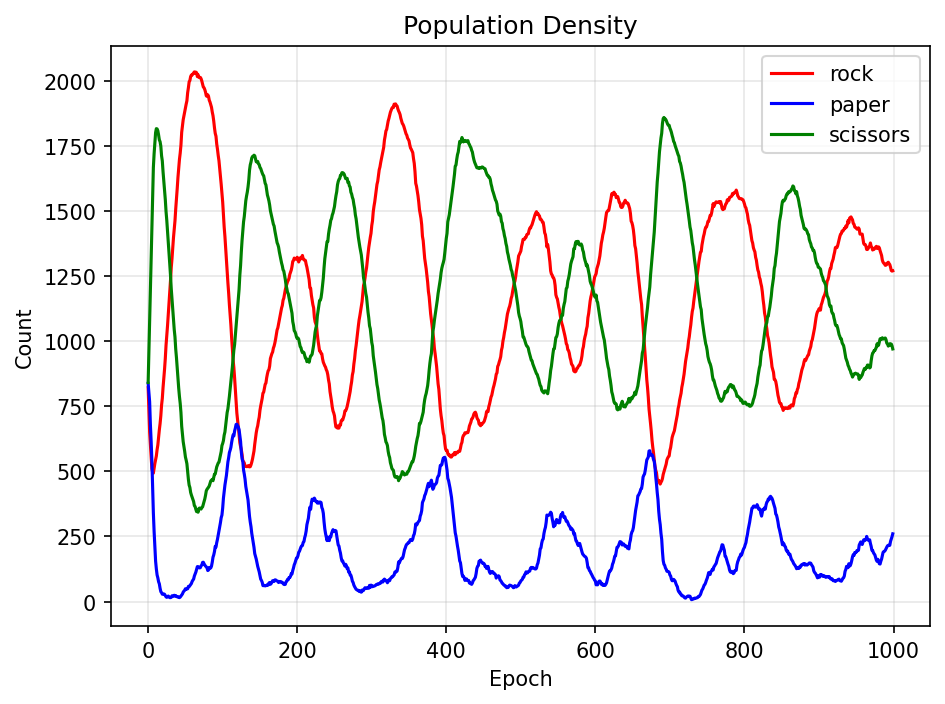

In [19]:
plot_densities(data)

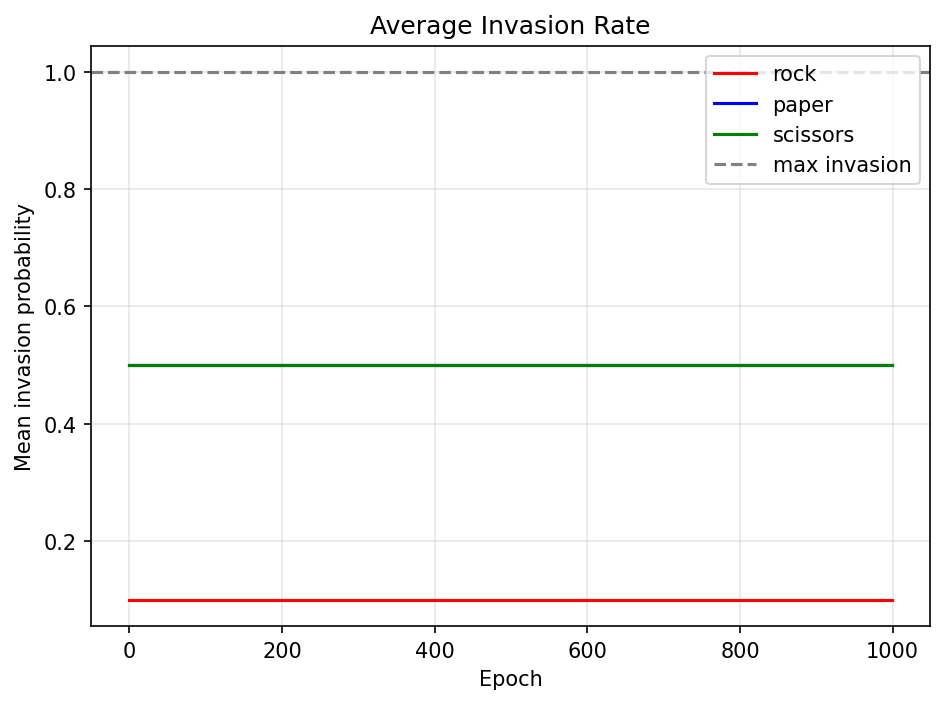

In [20]:
plot_average_invasions(data)

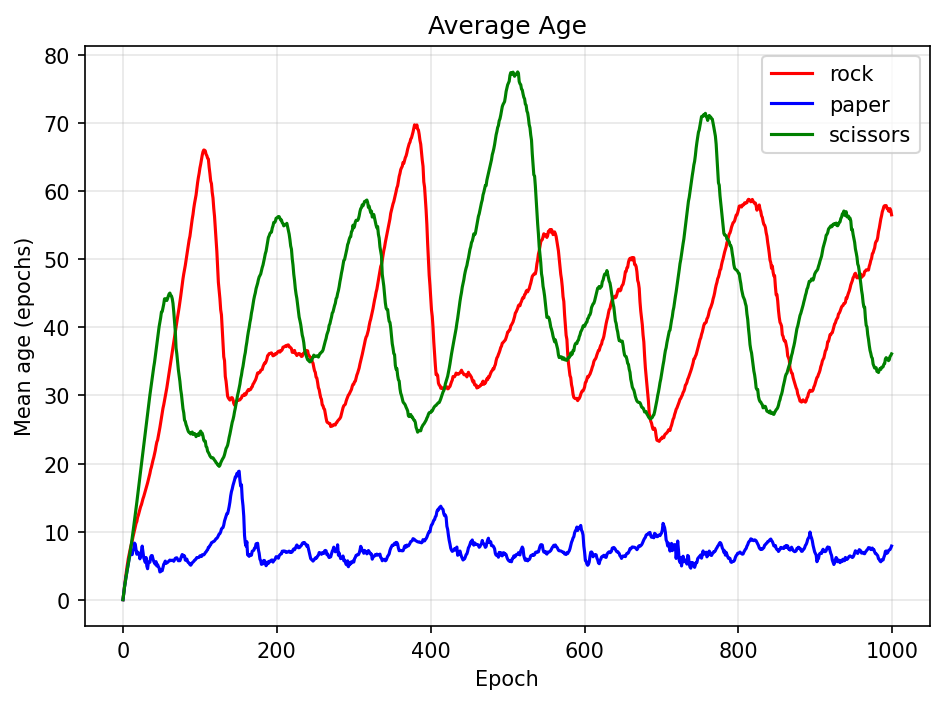

In [21]:
plot_average_age(data)

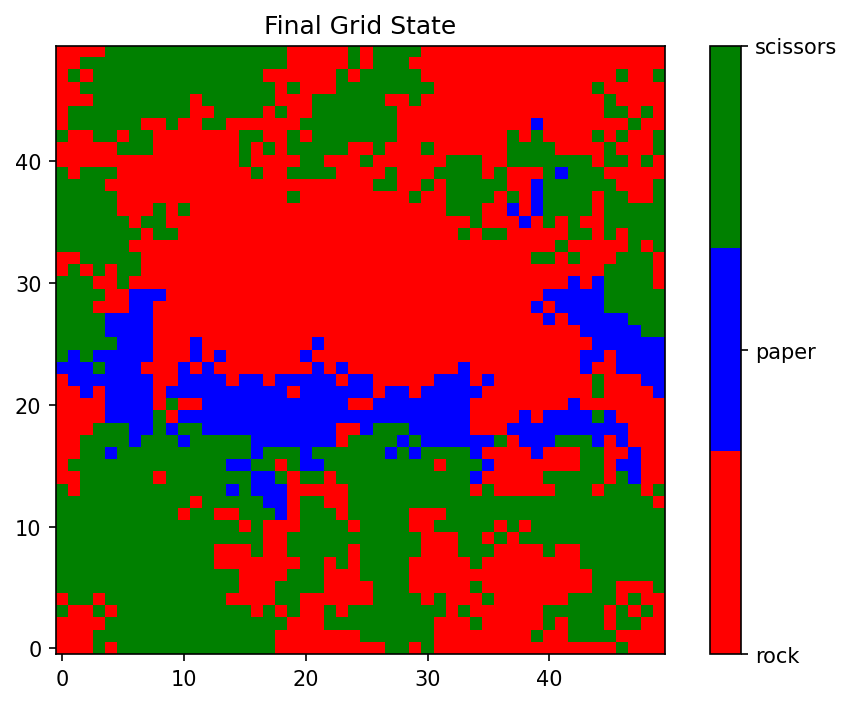

In [22]:
visualize_grid(model)

### Stochastic Mutation of 1 Specie

The other main result shown was obtained by keeping two species invasion
probabilites fixed, while the third can mutate.

Here the end result can vary, depending on initial conditions and initial
invasion probabilities assigned to each specie.

In the following simulations are shown two main scenarios:

- Every specie starts with an initial invasion rate of $0.5$.
- The evolvable specie starts with a low invasion rate of $0.1$.

The two models might converge to the same result, since in the paper is said
that the mutated specie tends to be more aggressive in the end.

In [23]:
policies = {
    "rock": evo.Stochastic(sigma=0.1),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=50,
    policies=policies,
    initial_invasions=[0.5, 0.5, 0.5],
    rng=42,
)

model.run_for(1000, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,821,838,841,0.500000,0.5,0.5,0.000000,0.000000,0.000000
1,831,828,841,0.498641,0.5,0.5,1.000000,1.000000,1.000000
2,844,823,833,0.497059,0.5,0.5,1.847156,1.862697,1.855942
3,866,821,813,0.498313,0.5,0.5,2.563510,2.600487,2.608856
4,848,843,809,0.498392,0.5,0.5,3.227594,3.196916,3.241038
...,...,...,...,...,...,...,...,...,...
995,857,861,782,0.823119,0.5,0.5,7.522754,11.393728,9.101023
996,866,867,767,0.821739,0.5,0.5,7.572748,10.675894,9.033898
997,886,878,736,0.819495,0.5,0.5,7.620767,10.333713,9.127717
998,879,909,712,0.820188,0.5,0.5,7.736064,9.827283,9.040730


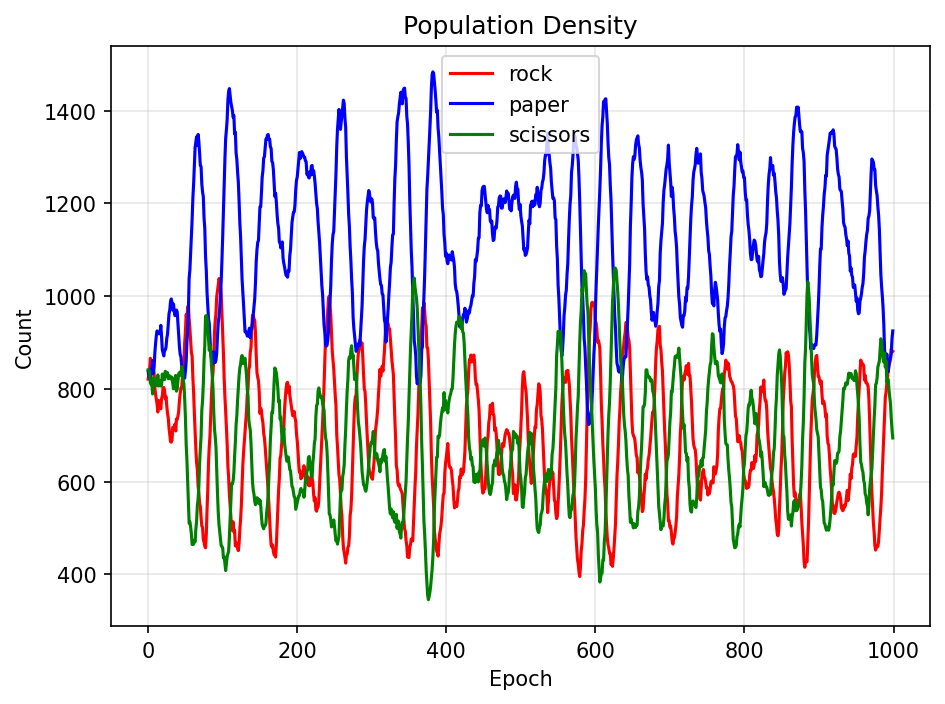

In [24]:
plot_densities(data)

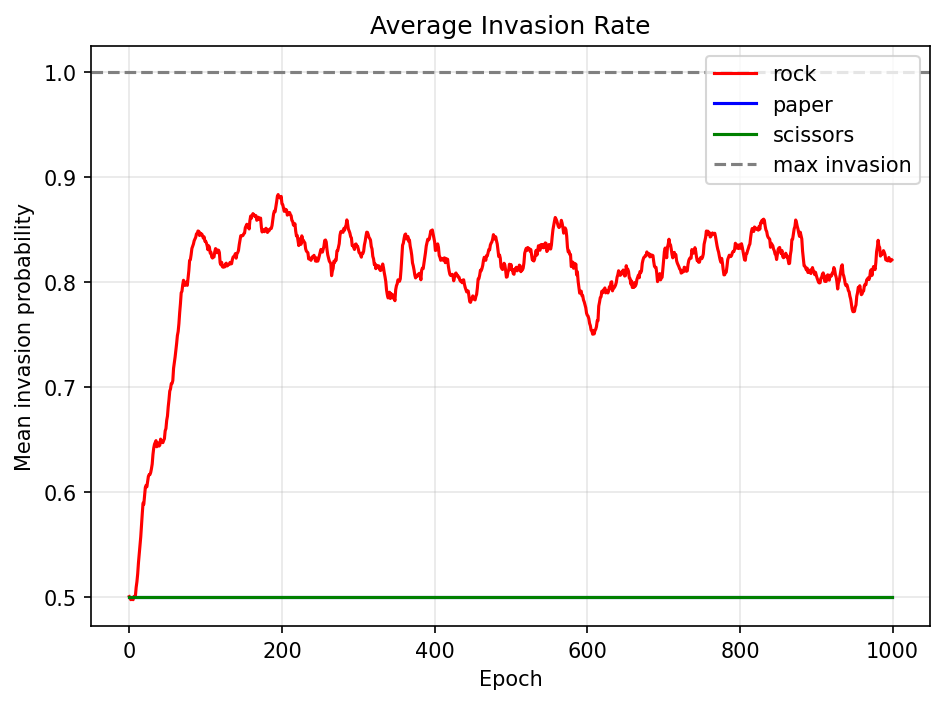

In [25]:
plot_average_invasions(data)

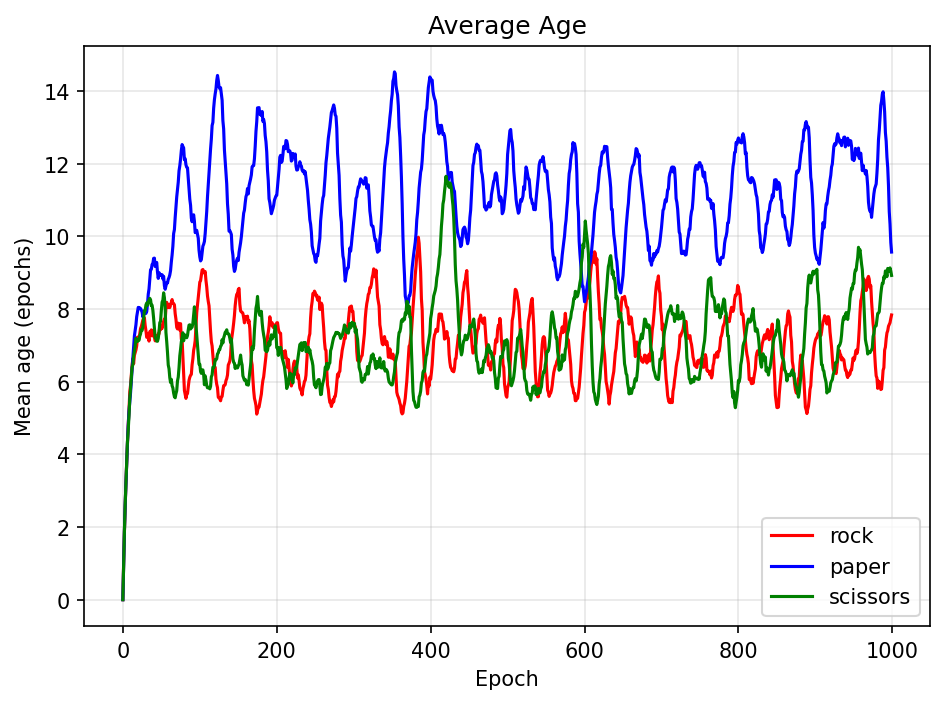

In [26]:
plot_average_age(data)

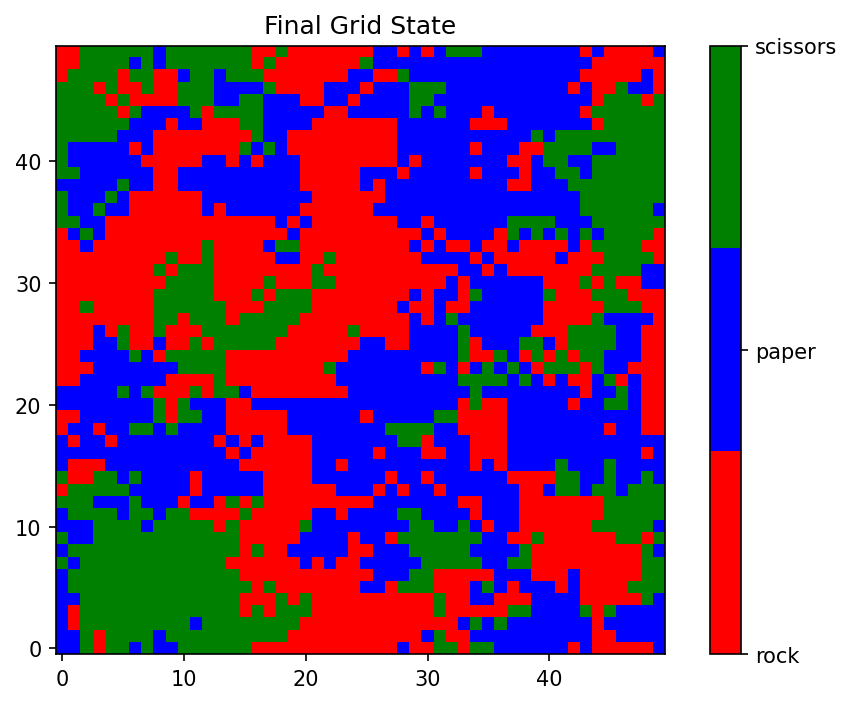

In [27]:
visualize_grid(model)

In [28]:
policies = {
    "rock": evo.Stochastic(sigma=0.1),
    "paper": evo.Inheritance(),
    "scissors": evo.Inheritance(),
}

model = RPSModel(
    dim=50,
    policies=policies,
    initial_invasions=[0.1, 0.5, 0.5],
    rng=42,
)

model.run_for(1000, verbose=False)
data = model.datacollector.get_model_vars_dataframe()
data

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age
0,821,838,841,0.100000,0.5,0.5,0.000000,0.000000,0.000000
1,741,798,961,0.101207,0.5,0.5,1.000000,1.000000,1.000000
2,661,759,1080,0.100679,0.5,0.5,1.969743,1.878788,1.869444
3,610,676,1214,0.101878,0.5,0.5,2.885246,2.674556,2.625206
4,560,613,1327,0.103398,0.5,0.5,3.762500,3.362153,3.351922
...,...,...,...,...,...,...,...,...,...
995,689,1318,493,0.804318,0.5,0.5,7.246734,11.079666,6.020284
996,685,1337,478,0.797081,0.5,0.5,7.322628,11.275243,6.066946
997,661,1354,485,0.792674,0.5,0.5,7.437216,11.355982,6.047423
998,603,1380,517,0.788480,0.5,0.5,7.550580,11.252899,5.909091


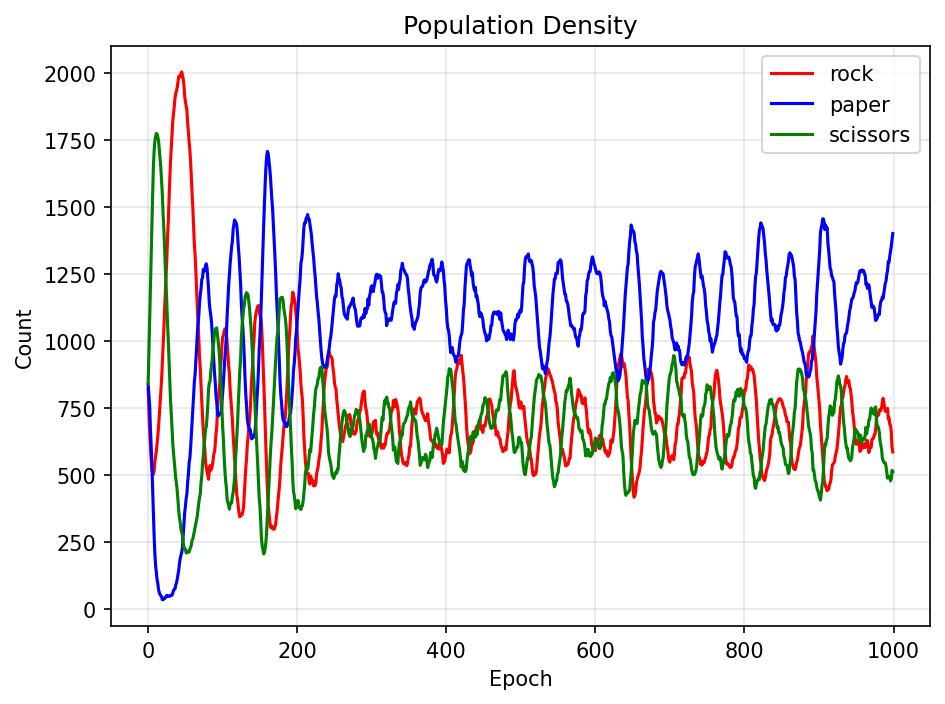

In [29]:
plot_densities(data)

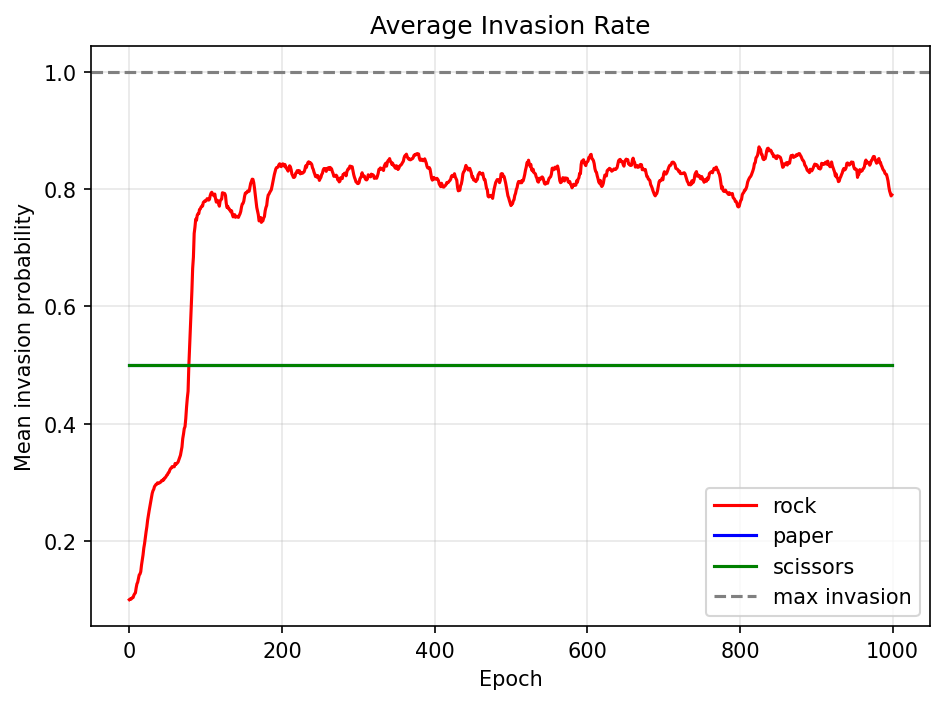

In [30]:
plot_average_invasions(data)

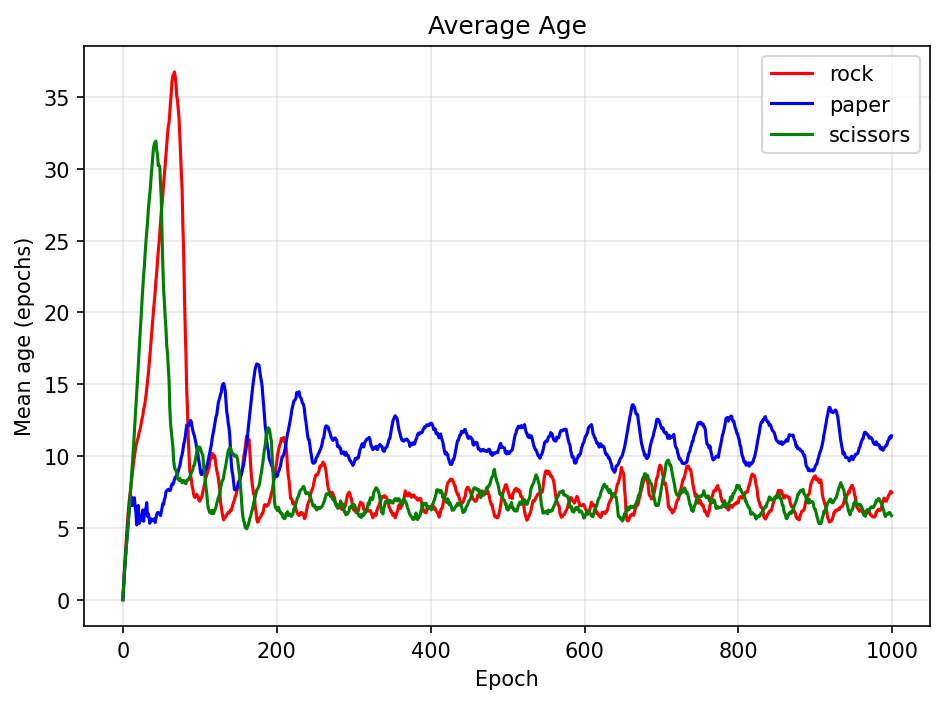

In [31]:
plot_average_age(data)

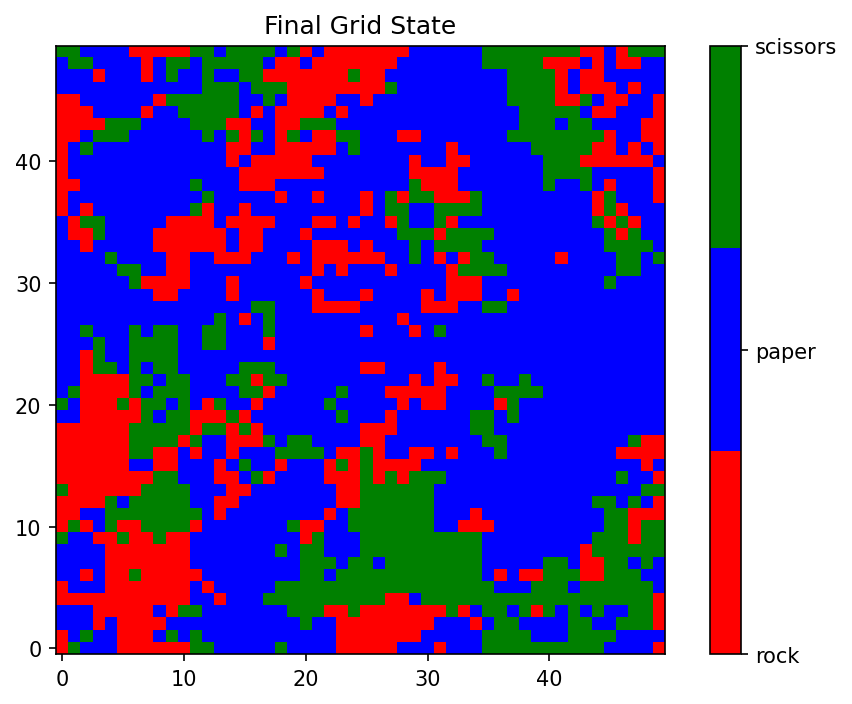

In [32]:
visualize_grid(model)

## Proposed Extension

The proposed extension adds a more structured dynamics of evolution and
reproduction. It is based on the assumption that _older_ individuals may have a
better strategy to survive.

In this perspective the proposed reproduction method is extended by **mating**
with _near_ and _fit_ individuals, trying to obtain a long-lived population.